# Technical Assessment 5

In [2]:
%pip install pandas matplotlib seaborn numpy

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.5 MB 1.2 MB/s eta 0:00:08
   --- ------------------------------------ 0.8/9.5 MB 1.0 MB/s eta 0:00:09
   --- ------------------------------------ 0.8/9.5 MB 1.0 MB/s eta 0:00:09
   ---- ----------------------------------- 1.0/9.5 MB 923.1 kB/s eta 0:00:10
   ---- ----------------------------------- 1.0/9.5 MB 923.1 kB/s eta 0:00:10
   ----- ---------------------------------- 1.3/9.5 MB 795.2 kB/s eta 0:00:11
   ----- ---------------------------------- 1.3/9.5 MB 795.2 kB/s eta 0:00:11
   ------ --------------------------------- 1.6/9.5 MB 784.2 kB/s eta 0:00:11
   ------- -------------------------------- 1.8/9.5 MB 787.4 kB/s eta 0:00:10
   -------- ------------------------------- 2.1/9.5 MB 828.1 kB/s eta 0:00:09
   -------- -------

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

%matplotlib inline

Matplotlib is building the font cache; this may take a moment.



--- 1. The Drivers of Wealth: Feature Correlation ---


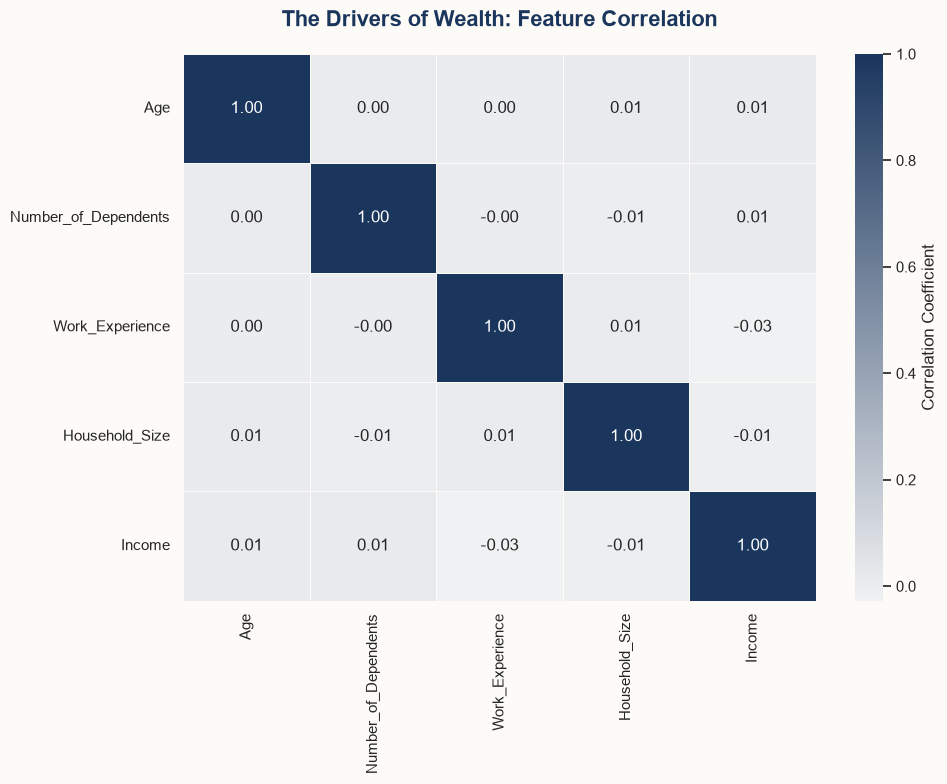


--- 2. Income Ceilings by Educational Attainment ---


C:\Users\Dawn\AppData\Local\Temp\ipykernel_22232\3509344197.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


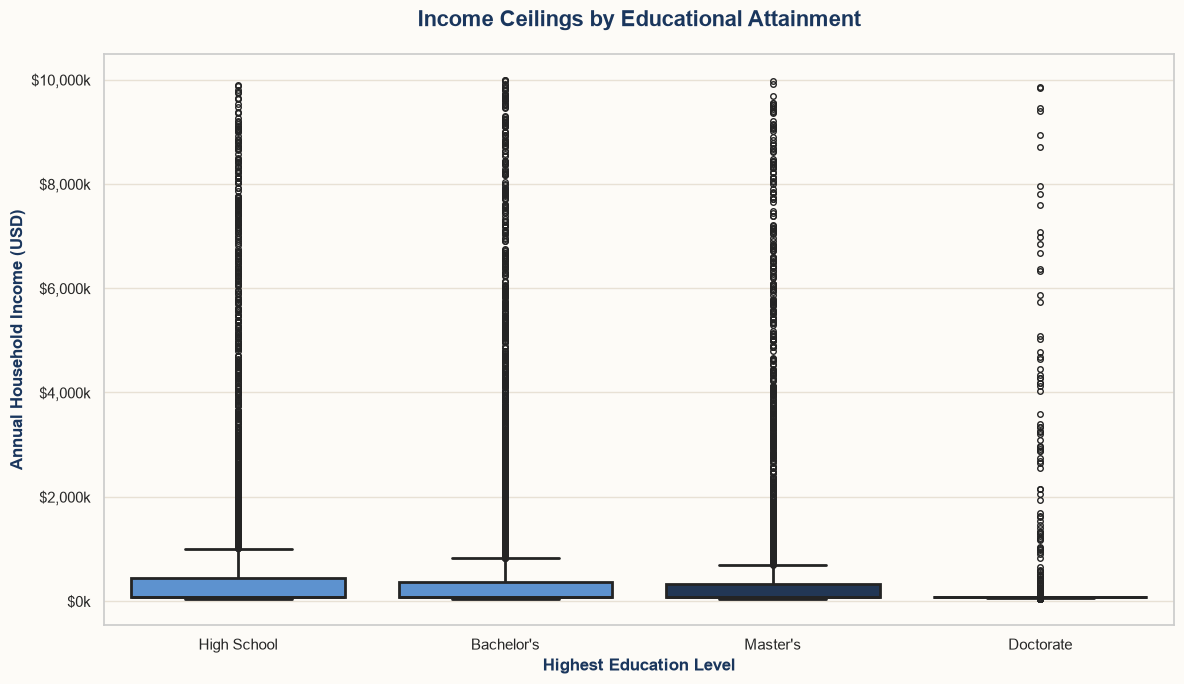


--- 3. Financial Return on Years of Work Experience ---


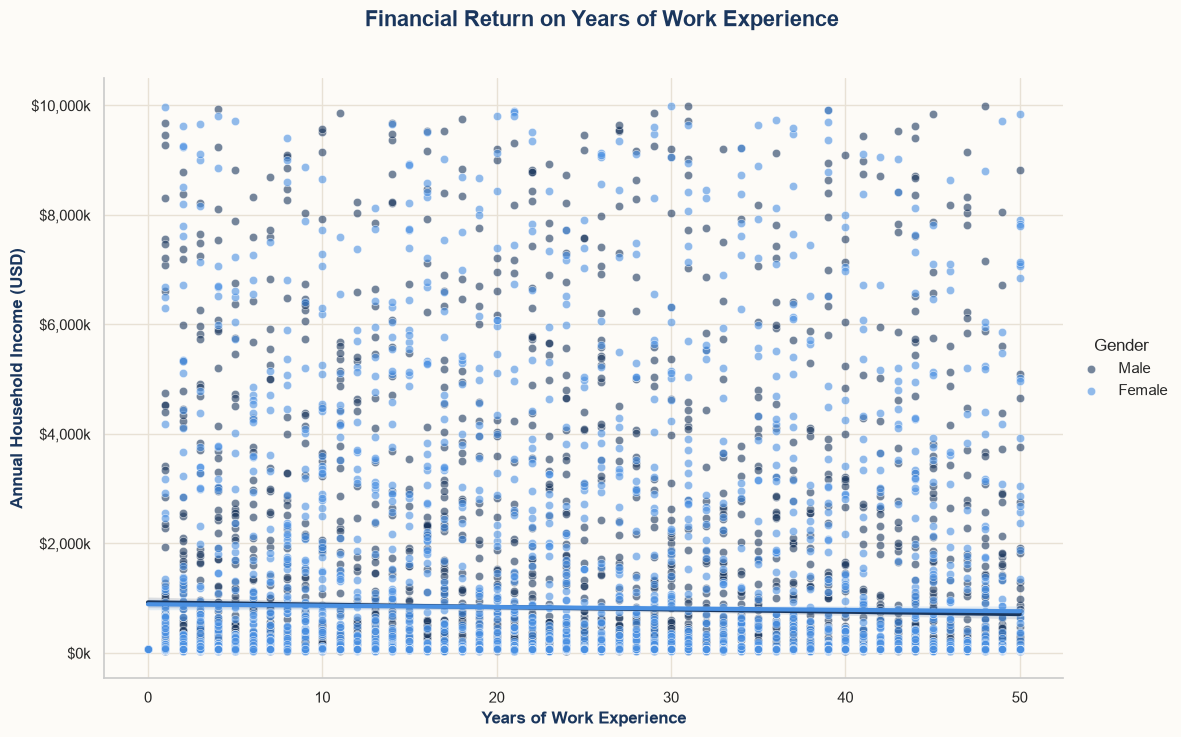


--- 4. Income Disparities by Commute and Geography ---


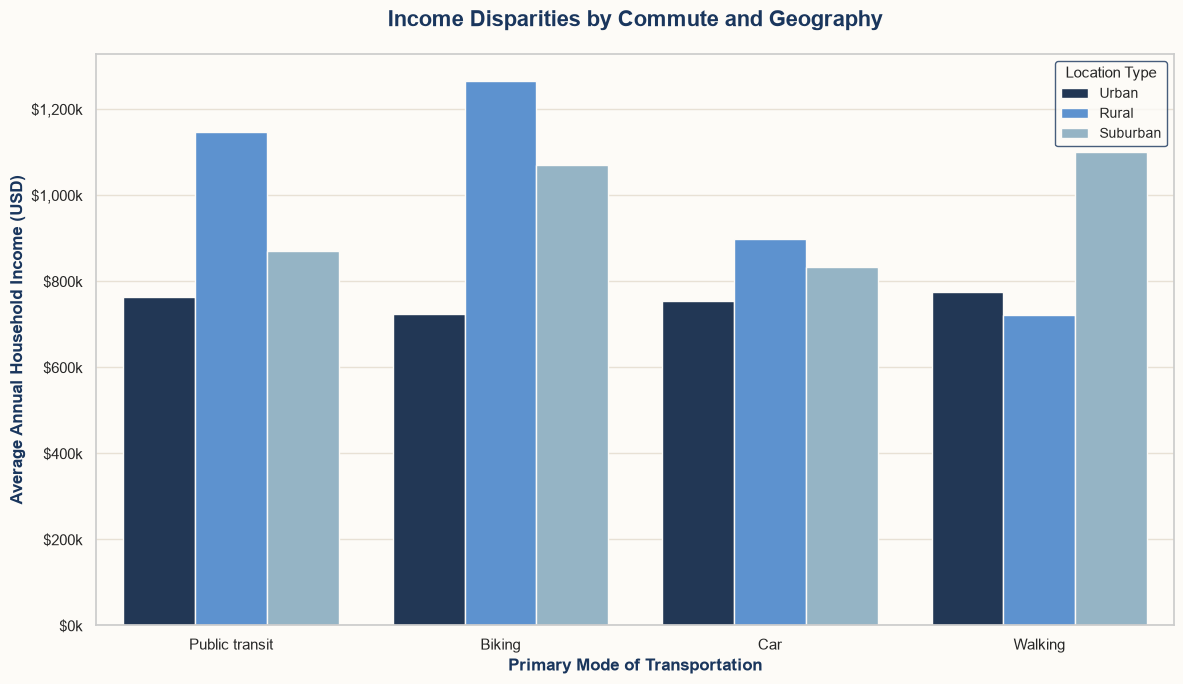


Execution Complete. All visualizations are perfectly generated!


In [7]:
# ==========================================
# 0. ENVIRONMENT SETUP (Run this once if needed)
# ==========================================
# %pip install pandas matplotlib seaborn numpy

# ==========================================
# 1. IMPORTS & AESTHETICS
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Jupyter Magic Command to display plots inline
%matplotlib inline

# Defining the Blue & Cream color palette
colors = ['#1A365D', '#4A90E2', '#8DB6CD', '#FDFBF7', '#E8E1D5']

# Set the background to cream
sns.set_theme(
    style="whitegrid", 
    rc={
        "axes.facecolor": "#FDFBF7", 
        "figure.facecolor": "#FDFBF7",
        "grid.color": "#E8E1D5",
        "font.family": "sans-serif"
    }
)
sns.set_palette(sns.color_palette(colors[:3]))

# Load the dataset
df = pd.read_csv('dataviztechnical.csv')

# ==========================================
# 2. VISUALIZATION 1: THE CORRELATION HEATMAP
# ==========================================
print("\n--- 1. The Drivers of Wealth: Feature Correlation ---")
plt.figure(figsize=(10, 8))

# Using the exact updated numeric column names from your file
numeric_cols = ['Age', 'Number_of_Dependents', 'Work_Experience', 'Household_Size', 'Income']
corr_matrix = df[numeric_cols].corr()

# Custom colormap
cmap_blue_cream = sns.light_palette(colors[0], as_cmap=True)

sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap=cmap_blue_cream, 
    linewidths=0.5, 
    linecolor='#FDFBF7',
    cbar_kws={'label': 'Correlation Coefficient'}
)

plt.title('The Drivers of Wealth: Feature Correlation', fontsize=16, fontweight='bold', color=colors[0], pad=20)
plt.tight_layout()
plt.savefig('1_Correlation_Heatmap.png', dpi=300)
plt.show()

# ==========================================
# 3. VISUALIZATION 2: DISTRIBUTION OF WEALTH
# ==========================================
print("\n--- 2. Income Ceilings by Educational Attainment ---")
plt.figure(figsize=(12, 7))

# Updated to use 'Education_Level' and 'Income'
edu_order = ['High School', "Bachelor's", "Master's", "Doctorate"]

sns.boxplot(
    data=df, 
    x='Education_Level', 
    y='Income', 
    order=edu_order,
    palette=[colors[1], colors[1], colors[0], colors[0]],
    linewidth=2,
    fliersize=4
)

plt.title('Income Ceilings by Educational Attainment', fontsize=16, fontweight='bold', color=colors[0], pad=20)
plt.xlabel('Highest Education Level', fontsize=12, fontweight='bold', color=colors[0])
plt.ylabel('Annual Household Income (USD)', fontsize=12, fontweight='bold', color=colors[0])

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "${:,}k".format(int(x/1000))))

plt.tight_layout()
plt.savefig('2_Income_Distribution.png', dpi=300)
plt.show()

# ==========================================
# 4. VISUALIZATION 3: THE EXPERIENCE CURVE
# ==========================================
print("\n--- 3. Financial Return on Years of Work Experience ---")
g = sns.lmplot(
    data=df, 
    x='Work_Experience', 
    y='Income', 
    hue='Gender',
    palette=[colors[0], colors[1]], 
    height=7, 
    aspect=1.5,
    scatter_kws={'alpha': 0.6, 'edgecolor': 'white', 'linewidths': 0.5}, # Changed 'linewidth' to 'linewidths'
    line_kws={'linewidth': 3}
)

g.fig.suptitle('Financial Return on Years of Work Experience', fontsize=16, fontweight='bold', color=colors[0], y=1.05)
g.set_axis_labels('Years of Work Experience', 'Annual Household Income (USD)', fontsize=12, fontweight='bold', color=colors[0])
g.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "${:,}k".format(int(x/1000))))

plt.savefig('3_Experience_Curve.png', dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# 5. VISUALIZATION 4: LIFESTYLE BREAKDOWN
# ==========================================
print("\n--- 4. Income Disparities by Commute and Geography ---")
plt.figure(figsize=(12, 7))

# Updated to use 'Primary_Mode_of_Transportation' and 'Income'
sns.barplot(
    data=df, 
    x='Primary_Mode_of_Transportation', 
    y='Income', 
    hue='Location',
    palette=[colors[0], colors[1], colors[2]],
    errorbar=None,
    edgecolor='#FDFBF7'
)

plt.title('Income Disparities by Commute and Geography', fontsize=16, fontweight='bold', color=colors[0], pad=20)
plt.xlabel('Primary Mode of Transportation', fontsize=12, fontweight='bold', color=colors[0])
plt.ylabel('Average Annual Household Income (USD)', fontsize=12, fontweight='bold', color=colors[0])
plt.legend(title='Location Type', title_fontsize='11', fontsize='10', frameon=True, facecolor='#FDFBF7', edgecolor=colors[0])

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "${:,}k".format(int(x/1000))))

plt.tight_layout()
plt.savefig('4_Lifestyle_Breakdown.png', dpi=300)
plt.show()

print("\nExecution Complete. All visualizations are perfectly generated!")